# 📊 Telco Customer Churn — Predicción de Abandono de Clientes

**Autor:** Gonzalo Matos Montoya  
**Dataset:** [IBM Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Herramientas:** Python · pandas · matplotlib · seaborn · scikit-learn · XGBoost · SHAP

---

## 1. Formulación del Problema

### Contexto de negocio

Una empresa de telecomunicaciones enfrenta un problema común en la industria: **la pérdida de clientes** (conocida como *churn*). Adquirir un cliente nuevo cuesta entre 5 y 7 veces más que retener uno existente. Por eso, identificar a los clientes con mayor riesgo de abandono **antes de que se vayan** es una ventaja competitiva enorme.

Con un modelo predictivo, el equipo comercial puede priorizar acciones de retención (descuentos, llamadas proactivas, mejoras de plan) sobre los clientes con mayor probabilidad de churn.

### Tipo de tarea

**Clasificación binaria:** el modelo debe predecir si un cliente abandonará el servicio (`Churn = Yes`) o se quedará (`Churn = No`).

### Variable objetivo

- `Churn`: indica si el cliente abandonó la empresa en el último mes.
  - `Yes` → 1 (churn)
  - `No` → 0 (retención)

### Métrica principal: ROC-AUC

Usamos **ROC-AUC** como métrica principal porque:

- El dataset está **desbalanceado** (la mayoría de clientes no hacen churn), entonces el *accuracy* sería engañoso — un modelo que siempre predice "No" tendría ~73% de accuracy sin aprender nada.
- ROC-AUC mide qué tan bien el modelo **separa** clientes que hacen churn de los que no, independientemente del umbral de decisión.
- También reportamos **Recall** (sensibilidad): en este contexto, preferimos no perder un cliente en riesgo real aunque eso implique alguna falsa alarma.

### Hipótesis de partida

Existen patrones en el tipo de contrato, los servicios contratados, el tiempo de permanencia y los cargos mensuales que permiten anticipar qué clientes tienen mayor probabilidad de abandonar el servicio.

---
## 2. Librerías

In [ ]:
# Instalamos SHAP
!pip install shap -q

In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_curve,
    auc
)

# Explicabilidad
import shap

# Configuración general
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 3. Carga de Datos

El dataset se carga directamente desde un repositorio público. No es necesario descargarlo manualmente.

In [ ]:
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

df = pd.read_csv(URL)

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Filas: 7,043 | Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Tabla de Variables

| Variable | Tipo | Descripción |
|---|---|---|
| `customerID` | ID | Identificador único del cliente |
| `gender` | Categórica | Género del cliente |
| `SeniorCitizen` | Binaria | ¿Es adulto mayor? (0/1) |
| `Partner` | Binaria | ¿Tiene pareja? |
| `Dependents` | Binaria | ¿Tiene dependientes? |
| `tenure` | Numérica | Meses de permanencia en la empresa |
| `PhoneService` | Binaria | ¿Tiene servicio telefónico? |
| `MultipleLines` | Categórica | ¿Tiene múltiples líneas? |
| `InternetService` | Categórica | Tipo de servicio de internet |
| `OnlineSecurity` | Categórica | ¿Tiene seguridad online? |
| `OnlineBackup` | Categórica | ¿Tiene backup online? |
| `DeviceProtection` | Categórica | ¿Tiene protección de dispositivos? |
| `TechSupport` | Categórica | ¿Tiene soporte técnico? |
| `StreamingTV` | Categórica | ¿Tiene streaming de TV? |
| `StreamingMovies` | Categórica | ¿Tiene streaming de películas? |
| `Contract` | Categórica | Tipo de contrato (mensual, 1 año, 2 años) |
| `PaperlessBilling` | Binaria | ¿Usa facturación electrónica? |
| `PaymentMethod` | Categórica | Método de pago |
| `MonthlyCharges` | Numérica | Cargo mensual en USD |
| `TotalCharges` | Numérica | Cargo total acumulado en USD |
| `Churn` | **Target** | ¿El cliente abandonó? (Yes/No) |

In [ ]:
# Vista general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Tamaño del Dataset

In [ ]:
# Dimensión del Dataset
df.shape

(7043, 21)

Descripcion de Variables

In [ ]:
# Columnas del Dataset
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
# Estadísticas de variables categóricas
df.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [ ]:
df.select_dtypes(include='object').apply(pd.unique)

,0
customerID,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
gender,"[Female, Male]"
Partner,"[Yes, No]"
Dependents,"[No, Yes]"
PhoneService,"[No, Yes]"
MultipleLines,"[No phone service, No, Yes]"
InternetService,"[DSL, Fiber optic, No]"
OnlineSecurity,"[No, Yes, No internet service]"
OnlineBackup,"[Yes, No, No internet service]"
DeviceProtection,"[No, Yes, No internet service]"


### Distribución de la variable objetivo

Lo primero que queremos saber es qué tan desbalanceado está el dataset. Esto condiciona tanto las métricas que vamos a usar como la estrategia de modelado.

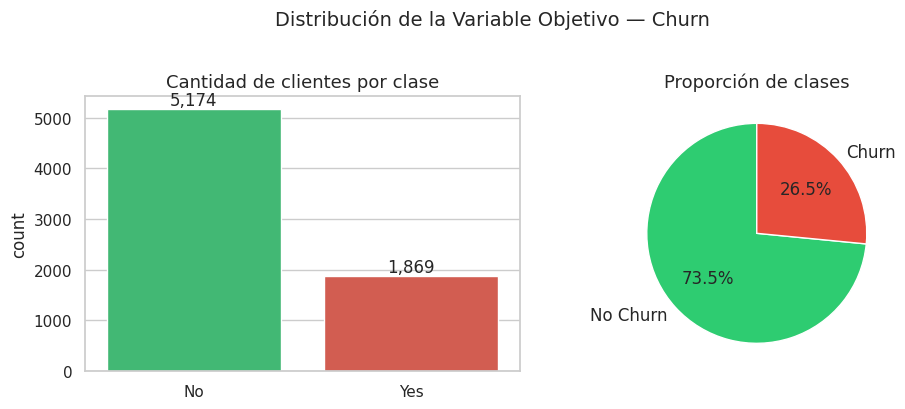

No Churn: 5,174 (73.5%)
Churn:    1,869 (26.5%)

⚠️  Dataset desbalanceado: la clase minoritaria (Churn=Yes) representa solo el 26.5% del total.
   Por eso usaremos ROC-AUC como métrica principal y class_weight="balanced" en los modelos.


In [ ]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo absoluto
sns.countplot(data=df, x='Churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Cantidad de clientes por clase', fontsize=13)
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Porcentaje
axes[1].pie(churn_counts, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción de clases', fontsize=13)

plt.suptitle('Distribución de la Variable Objetivo — Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'No Churn: {churn_counts["No"]:,} ({churn_pct["No"]:.1f}%)')
print(f'Churn:    {churn_counts["Yes"]:,} ({churn_pct["Yes"]:.1f}%)')
print(f'\n⚠️  Dataset desbalanceado: la clase minoritaria (Churn=Yes) representa solo el {churn_pct["Yes"]:.1f}% del total.')
print('   Por eso usaremos ROC-AUC como métrica principal y class_weight="balanced" en los modelos.')

#Data Wrangling: Limpieza y Transformación de Datos

Valores Nulos

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Valores Duplicados

In [ ]:
df.duplicated().sum()

np.int64(0)

Missing Values

In [ ]:
missing_values = df.isna().sum()
missing_values[missing_values > 0]

,0


In [ ]:
# Conversion de columna TotalCharges de Object a Float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

In [ ]:
# Verificacion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##EDA

Cuantos Clientes abandonan?

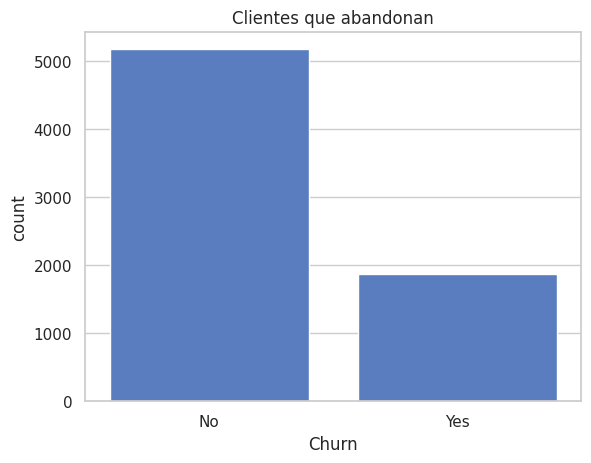

In [ ]:
sns.countplot(data=df,x='Churn')
plt.title('Clientes que abandonan')
plt.show()

Relacion entre Antigüedad y Abandono

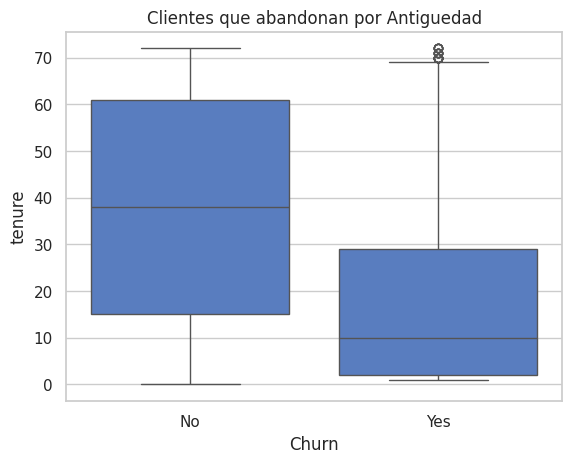

In [ ]:
sns.boxplot(data=df,x='Churn',y='tenure')
plt.title('Clientes que abandonan por Antiguedad')
plt.show()

Interpretación:

caja baja → clientes nuevos.

caja alta → clientes antiguos.

¿Los cargos mensuales influyen?

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

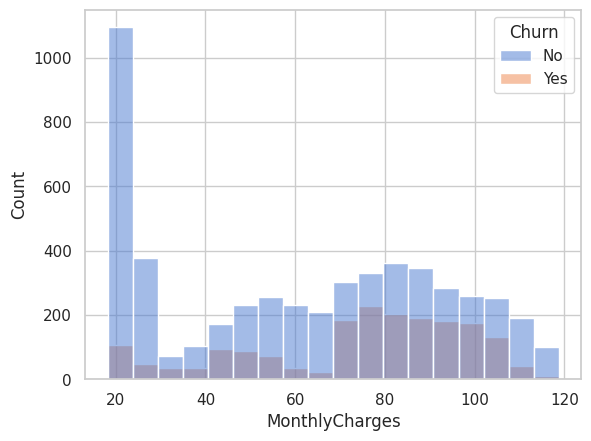

In [ ]:
sns.histplot(data=df,x="MonthlyCharges",hue="Churn")

Contrac vs Churn

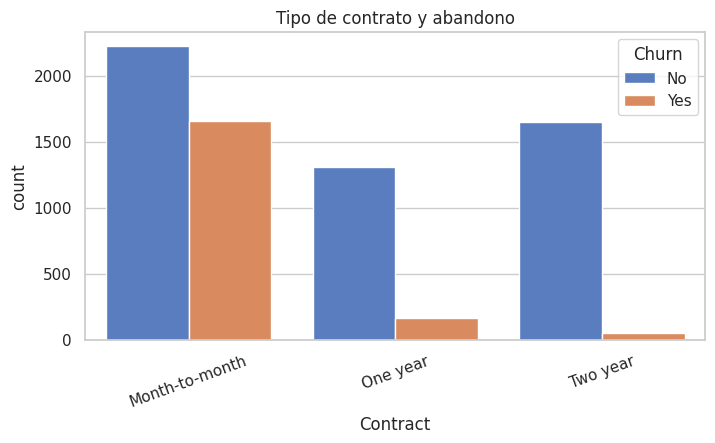

In [ ]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Tipo de contrato y abandono")
plt.xticks(rotation=20)
plt.show()

Internet Service

<Axes: xlabel='InternetService', ylabel='count'>

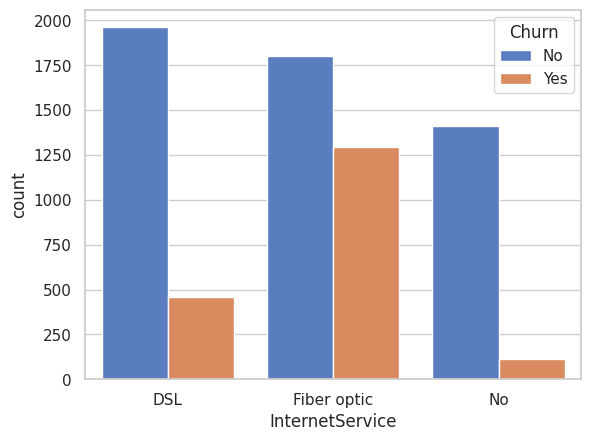

In [ ]:
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

Metodo de Pagos

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

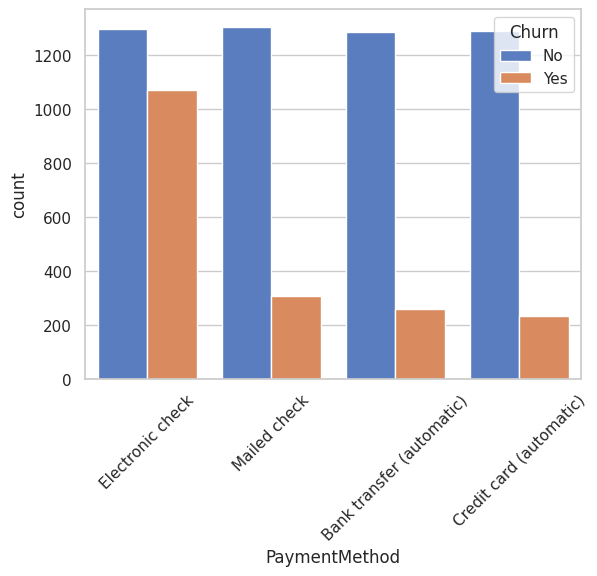

In [ ]:
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=45)

SeniorCitizen

<Axes: xlabel='SeniorCitizen', ylabel='count'>

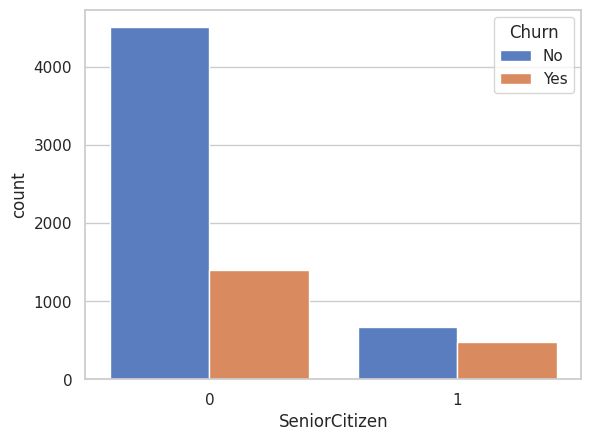

In [ ]:
sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

Correlacion

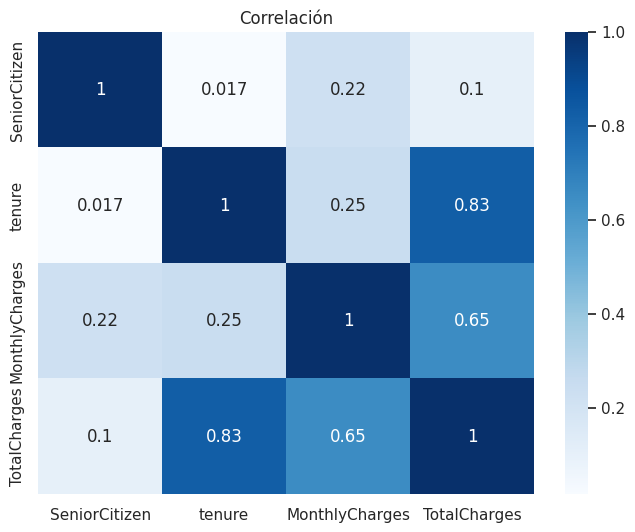

In [ ]:
numericas = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numericas.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlación")
plt.show()

# Ingenieria de Atributos

Preparación variable objetivo

In [ ]:
X = df.drop('Churn',axis=1)
y = df['Churn']

In [ ]:
#conversion de nvariable obnjetivo a binaria
y.replace({'No':0,'Yes':1},inplace=True)
y.value_counts()

,count
Churn,
0,5174
1,1869


#Creacion de nuevas variables

### Variable: ClienteNuevo

Se crea una variable binaria que identifica a los clientes con menos de 12 meses de antigüedad.

Esta transformación busca capturar el comportamiento observado en el EDA, donde los clientes más recientes presentan una mayor tasa de abandono.

In [ ]:
df["ClienteNuevo"] = (df["tenure"] < 12).astype(int)

### Variable: GastoPromedioMensual

Se calcula el gasto promedio por mes dividiendo el gasto total por la antigüedad del cliente.

Esta variable permite comparar el nivel de consumo entre clientes con diferentes tiempos de permanencia.

In [ ]:
# se utiliza +1 paraevitar division por 0
df["GastoPromedioMensual"] = (df["TotalCharges"]/(df["tenure"] + 1))

### Variable: ContratoLargo

Se crea una variable binaria que diferencia contratos mensuales de contratos de largo plazo.

El objetivo es facilitar que el modelo capture la estabilidad asociada a contratos de mayor duración.

In [ ]:
df["ContratoLargo"] = (df["Contract"] != "Month-to-month").astype(int)

### Variable: CantidadServicios

El dataset tiene columnas como:

* OnlineSecurity
* OnlineBackup
* DeviceProtection
* TechSupport
* StreamingTV
* StreamingMovies





En lugar de analizarlas por separado, podemos contar cuántos servicios adicionales contrató cada cliente.

In [ ]:
servicios = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["CantidadServicios"] = (df[servicios] == "Yes").sum(axis=1)

###Variable: CargosAltos

Se crea una variable binaria para observar si los clientes con un cargo mensual alto tiene mas probabilidad de abadono

In [ ]:
umbral = df["MonthlyCharges"].median()

df["CargosAltos"] = (df["MonthlyCharges"] > umbral).astype(int)

### Verificacion

Después de crear las variables, se verifica que existen.

In [ ]:
nuevas = [
    "ClienteNuevo",
    "GastoPromedioMensual",
    "ContratoLargo",
    "CantidadServicios",
    "CargosAltos"
]

df[nuevas].head()

,ClienteNuevo,GastoPromedioMensual,ContratoLargo,CantidadServicios,CargosAltos
0,1,14.925000,0,1,0
1,0,53.985714,1,2,0
2,1,36.050000,0,2,0
3,0,40.016304,1,3,0
4,1,50.550000,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7043 non-null   object 
 1   gender                7043 non-null   object 
 2   SeniorCitizen         7043 non-null   int64  
 3   Partner               7043 non-null   object 
 4   Dependents            7043 non-null   object 
 5   tenure                7043 non-null   int64  
 6   PhoneService          7043 non-null   object 
 7   MultipleLines         7043 non-null   object 
 8   InternetService       7043 non-null   object 
 9   OnlineSecurity        7043 non-null   object 
 10  OnlineBackup          7043 non-null   object 
 11  DeviceProtection      7043 non-null   object 
 12  TechSupport           7043 non-null   object 
 13  StreamingTV           7043 non-null   object 
 14  StreamingMovies       7043 non-null   object 
 15  Contract             

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ClienteNuevo,GastoPromedioMensual,ContratoLargo,CantidadServicios,CargosAltos
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,14.925000,0,1,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,0,53.985714,1,2,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1,36.050000,0,2,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0,40.016304,1,3,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,50.550000,0,0,1


Seprarar Variables númericas y categóricas

In [ ]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

In [ ]:
cat_features = X.select_dtypes(include="object").columns

num_features = X.select_dtypes(exclude="object").columns

print(cat_features)

print(num_features)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ClienteNuevo', 'GastoPromedioMensual', 'ContratoLargo',
       'CantidadServicios', 'CargosAltos'],
      dtype='object')


Crear Preprocesador

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            num_features
        ),

        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            cat_features
        )

    ],

    remainder="drop"

)



*   StandardScaler() deja todas las variables numéricas en la misma escala.
*   OneHotEncoder() convierte las variables categóricas en columnas binarias

*   drop="first" evita multicolinealidad en modelos lineales.
*  handle_unknown="ignore" evita errores si aparecen categorías nuevas en producción.



#Dividir Train Test

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

¿Por qué usamos stratify?

Porque mantiene la misma proporción de Churn.Esto hace que la evaluación sea más confiable.

#Regresion Logística

Construiremos un Pipeline.

In [ ]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42,
                                      max_iter=1000))
])

Entrenamos.

In [ ]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ClienteNuevo', 'GastoPromedioMensual', 'ContratoLargo',
       'CantidadServicios', 'CargosAltos'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

Predicciones

In [ ]:
pred_log = logistic_model.predict(X_test)
print(classification_report(y_test,pred_log))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



Probabilidades

In [ ]:
prob_log = logistic_model.predict_proba(X_test)[:,1]
print(roc_auc_score(y_test,prob_log))

0.8460203053553438


Evaluación

In [ ]:
print("Accuracy :",accuracy_score(y_test,pred_log))

print("Precision:",precision_score(y_test,pred_log))

print("Recall :",recall_score(y_test,pred_log))

print("F1 :",f1_score(y_test,pred_log))

print("ROC AUC :",roc_auc_score(y_test,prob_log))

Accuracy : 0.8041163946061036
Precision: 0.6666666666666666
Recall : 0.5240641711229946
F1 : 0.5868263473053892
ROC AUC : 0.8460203053553438


Matriz de confusión

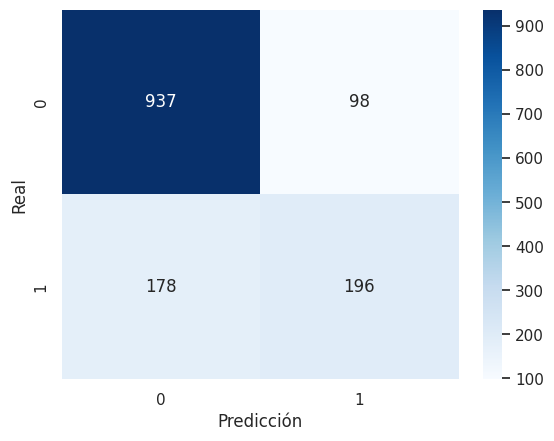

In [ ]:
cm = confusion_matrix(
    y_test,
    pred_log
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")

plt.ylabel("Real")

plt.show()

#Árbol de decisión

Construiremos un Pipeline.

In [ ]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     DecisionTreeClassifier(
         random_state=42
     ))
])

tree_model.fit(
    X_train,
    y_train
)

pred_tree = tree_model.predict(X_test)

prob_tree = tree_model.predict_proba(X_test)[:,1]

Evaluación

In [ ]:
print("Accuracy :",accuracy_score(y_test,pred_tree))

print("Precision:",precision_score(y_test,pred_tree))

print("Recall :",recall_score(y_test,pred_tree))

print("F1 :",f1_score(y_test,pred_tree))

print("ROC AUC :",roc_auc_score(y_test,prob_tree))

Accuracy : 0.7338537970191625
Precision: 0.49875311720698257
Recall : 0.5347593582887701
F1 : 0.5161290322580645
ROC AUC : 0.6700534759358289


#Random Forest

In [ ]:
forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     RandomForestClassifier(
         random_state=42
     ))
])

forest_model.fit(
    X_train,
    y_train
)

pred_forest = forest_model.predict(X_test)

prob_forest = forest_model.predict_proba(X_test)[:,1]

Evaluación

In [ ]:
print("Accuracy :",accuracy_score(y_test,pred_forest))

print("Precision:",precision_score(y_test,pred_forest))

print("Recall :",recall_score(y_test,pred_forest))

print("F1 :",f1_score(y_test,pred_forest))

print("ROC AUC :",roc_auc_score(y_test,prob_forest))

Accuracy : 0.78708303761533
Precision: 0.6284722222222222
Recall : 0.4839572192513369
F1 : 0.5468277945619335
ROC AUC : 0.8209989924823684


#XGBoost

In [ ]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     XGBClassifier(
         random_state=42,
         eval_metric="logloss"
     ))
])

xgb_model.fit(
    X_train,
    y_train
)

pred_xgb = xgb_model.predict(X_test)

prob_xgb = xgb_model.predict_proba(X_test)[:,1]

Evaluación

In [ ]:
print("Accuracy :",accuracy_score(y_test,pred_xgb))

print("Precision:",precision_score(y_test,pred_xgb))

print("Recall :",recall_score(y_test,pred_xgb))

print("F1 :",f1_score(y_test,pred_xgb))

print("ROC AUC :",roc_auc_score(y_test,prob_xgb))

Accuracy : 0.7785663591199432
Precision: 0.596875
Recall : 0.5106951871657754
F1 : 0.5504322766570605
ROC AUC : 0.8220672195096748


# Evaluar todos los modelos

In [ ]:
def evaluar_modelo(nombre, modelo, X_test, y_test):

    pred = modelo.predict(X_test)
    prob = modelo.predict_proba(X_test)[:,1]

    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob)
    }

In [ ]:
resultados = pd.DataFrame([

    evaluar_modelo(
        "Logistic Regression",
        logistic_model,
        X_test,
        y_test
    ),

    evaluar_modelo(
        "Decision Tree",
        tree_model,
        X_test,
        y_test
    ),

    evaluar_modelo(
        "Random Forest",
        forest_model,
        X_test,
        y_test
    ),

    evaluar_modelo(
        "XGBoost",
        xgb_model,
        X_test,
        y_test
    )

])

resultados.sort_values(
    by="F1",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.804116,0.666667,0.524064,0.586826,0.846020
3,XGBoost,0.778566,0.596875,0.510695,0.550432,0.822067
2,Random Forest,0.787083,0.628472,0.483957,0.546828,0.820999
1,Decision Tree,0.733854,0.498753,0.534759,0.516129,0.670053


### Optimizacion de Modelos: GridSearchCV

Hiperparámetros

In [ ]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

In [ ]:
pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

Entrenamiento

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ClienteNuevo', 'GastoPromedioMensual', 'ContratoLargo',
       'CantidadServicios', 'CargosAltos'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         Index...
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=1)

Mejores Hiperparámentros:

In [ ]:
grid_rf.best_params_

{'classifier__max_depth': 10,
 'classifier__min_samples_leaf': 4,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 300}

Mejor resultado

In [ ]:
grid_rf.best_score_

np.float64(0.8445350745838993)

Evaluación del modelo

In [ ]:
best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7970
Precision: 0.6477
Recall   : 0.5160
F1-Score : 0.5744
ROC-AUC  : 0.8440


### Matriz de Confusión

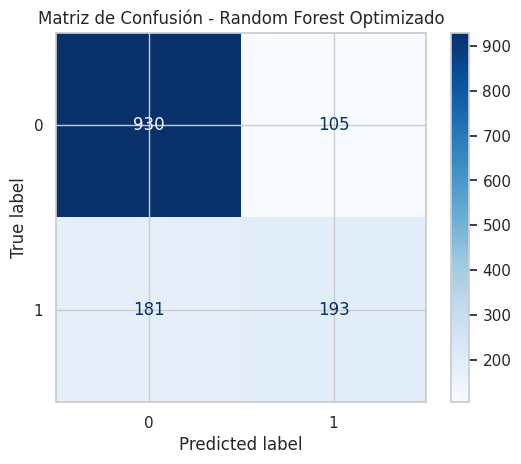

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Matriz de Confusión - Random Forest Optimizado")
plt.show()

 ### Curva ROC

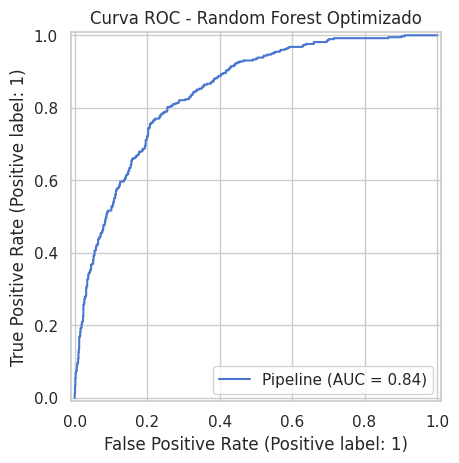

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

plt.title("Curva ROC - Random Forest Optimizado")
plt.show()

### Shap

Hasta este punto se entrenaron y optimizaron diferentes modelos de clasificación para predecir el abandono de clientes.

Sin embargo, obtener una buena métrica de desempeño no es suficiente en un contexto empresarial. Es necesario comprender qué variables influyen en las predicciones para generar confianza en el modelo y facilitar la toma de decisiones.

Por este motivo se utiliza SHAP (SHapley Additive exPlanations), una técnica de interpretabilidad que permite cuantificar la contribución de cada variable en las predicciones del modelo.

#### Transformacion de datos

In [ ]:
X_train_transformed = best_rf.named_steps["preprocessor"].transform(X_train)
X_test_transformed = best_rf.named_steps["preprocessor"].transform(X_test)

Obtener el nombre de las variables

In [ ]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
print(feature_names)

['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__ClienteNuevo' 'num__GastoPromedioMensual'
 'num__ContratoLargo' 'num__CantidadServicios' 'num__CargosAltos'
 'cat__gender_Male' 'cat__Partner_Yes' 'cat__Dependents_Yes'
 'cat__PhoneService_Yes' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No internet service'
 'cat__StreamingMovies_Yes' 'cat__Contract_One year'
 'cat__Contract_Two year' 'cat__PaperlessBilling_Yes'
 'cat__PaymentMethod_Credit card (automatic)'
 'cat__PaymentMethod_Electronic check' 'cat__PaymentMethod_Mailed 

Nombre del Modelo

In [ ]:
rf_model = best_rf.named_steps["classifier"]
print(rf_model)

RandomForestClassifier(max_depth=10, min_samples_leaf=4, n_estimators=300,
                       random_state=42)


Crear el Explainer

In [ ]:
import shap

explainer = shap.Explainer(rf_model)

Calculas Valores de Shap

In [ ]:
shap_values = explainer(X_test_transformed)

# Summary Plot

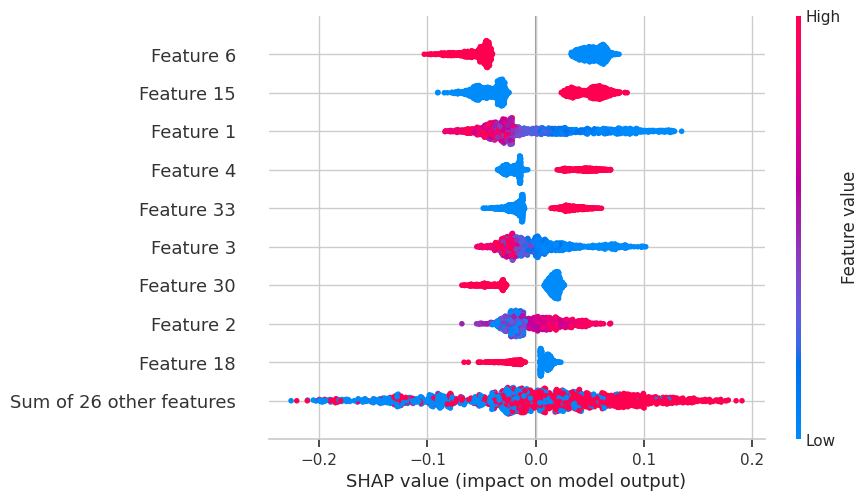

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 1])

Waterfall Plot

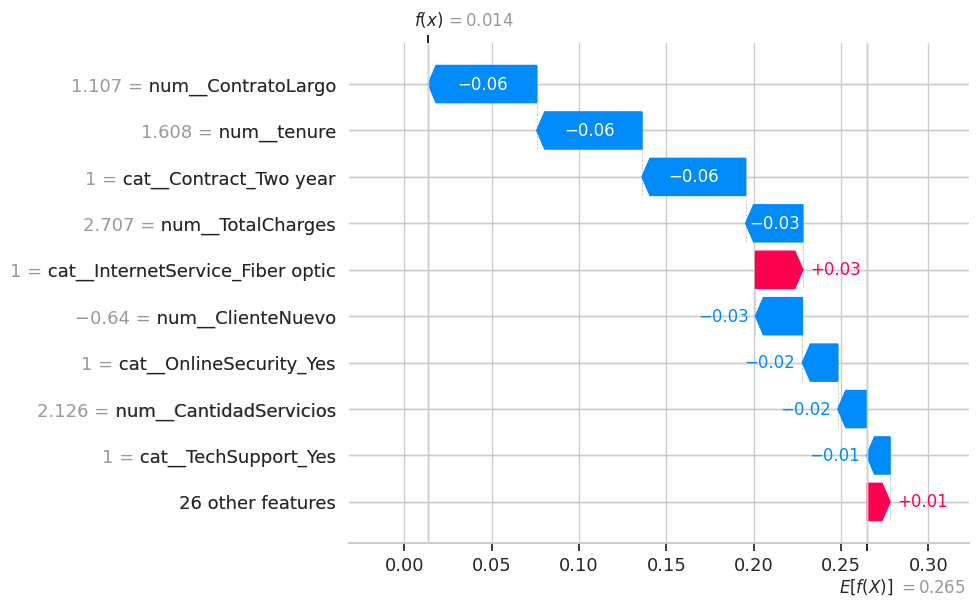

In [ ]:
indice = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[indice, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_transformed[indice],
        feature_names=feature_names
    )
)

SHAP Bar Plot

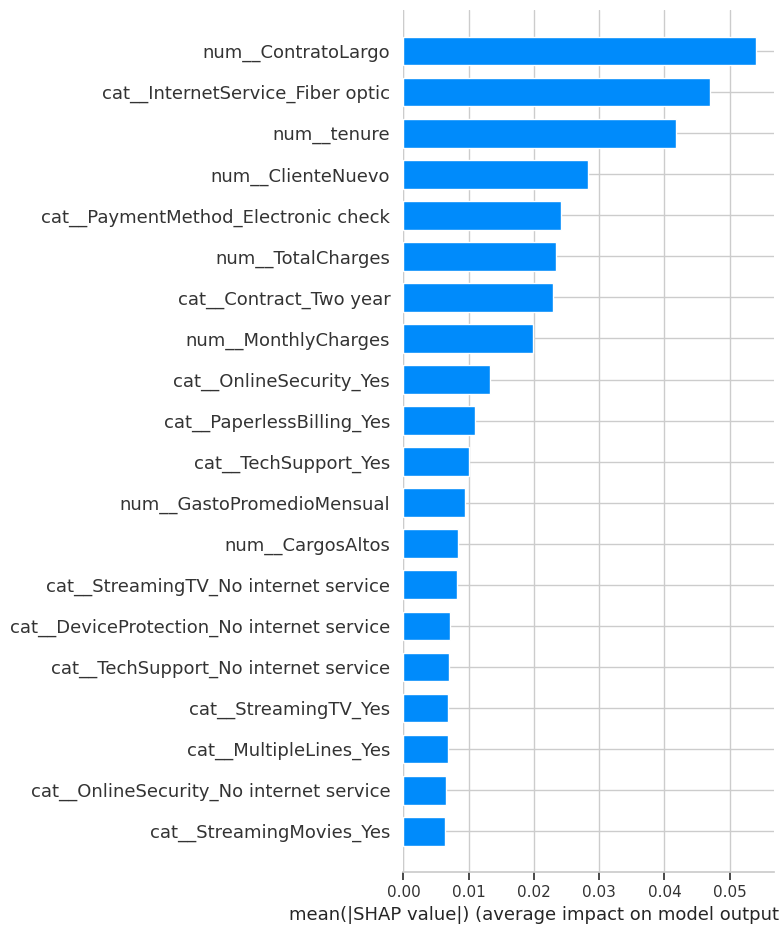

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

El gráfico de barras muestra la importancia media absoluta de cada variable en las predicciones del modelo. A diferencia del Summary Plot, no refleja la dirección del efecto, sino únicamente la magnitud de la influencia de cada característica.

### Interpretación de los resultados

El análisis mediante SHAP permitió identificar las variables con mayor influencia en las predicciones del modelo.

Se observa que la antigüedad del cliente (`tenure`) es la característica más importante. Los clientes con menor permanencia presentan una mayor probabilidad de abandono, mientras que una mayor antigüedad reduce significativamente dicho riesgo.

Asimismo, el tipo de contrato constituye otro factor determinante. Los contratos mensuales incrementan la probabilidad de churn, mientras que los contratos anuales y bianuales favorecen la permanencia del cliente.

Finalmente, variables relacionadas con el gasto mensual y la contratación de servicios adicionales también contribuyen a la predicción, aunque con una influencia menor.

Los resultados obtenidos mediante SHAP son consistentes con las conclusiones del análisis exploratorio, lo que incrementa la confianza en el comportamiento del modelo.

###  Conclusiones

En este proyecto desarrollé un modelo de Machine Learning para predecir el abandono de clientes de una empresa de telecomunicaciones utilizando el dataset Telco Customer Churn.

A lo largo del análisis pude comprender mejor el proceso completo de un proyecto de Data Science: desde la limpieza de los datos y el análisis exploratorio, hasta la creación de nuevas variables, el entrenamiento de distintos modelos y la optimización de hiperparámetros.

Además, el uso de SHAP me permitió interpretar las predicciones del modelo y entender qué variables tuvieron mayor influencia en el churn. Esto fue una de las partes más interesantes del proyecto, ya que no solo importa obtener buenas métricas, sino también poder explicar por qué el modelo toma determinadas decisiones.

En general, considero que el modelo obtenido presenta un buen desempeño y demuestra cómo el análisis de datos puede ayudar a identificar clientes con mayor riesgo de abandono. Como mejora futura, me gustaría probar otros algoritmos, realizar una optimización más avanzada de hiperparámetros y experimentar con nuevas técnicas de ingeniería de atributos para seguir mejorando el rendimiento del modelo.
